# a04 Example - Bayesian Optimization using Ax over Laser-Fiber Alignment Benchtop: Global Raster Search

# Install External Libraries for Optimizer Implementation

In [1]:
# !python -m pip install ax-platform

# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from time import sleep

import pyscan as ps
# from pyscan.drivers.thorlabs.thorlabsct1p import ThorlabsCT1P # fiber z-stage
from pyscan.drivers.thorlabs.thorlabspm16_120 import ThorlabsPM16_120 # laser power meter
from laser_fiber_align_measure_functions import raster, get_measure_opt
from laser_fiber_align_plots import input_combined_output_init, input_combined_output_plot

## Setup devices

In [3]:
devices = ps.ItemAttribute()


devices.x1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 1)
devices.y1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 2)

devices.x2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 1)
devices.y2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 2)

devices.pm16_120 = ThorlabsPM16_120()

devices.laser = ps.PulseLaser('COM7')

COM7


## Define a measure function

In [4]:
def measure_power(expt):
    d = ps.ItemAttribute()
    d.power_pre_raster = devices.pm16_120.power
    raster(expt.devices)
    d.x1_voltage_raster = devices.x1.voltage
    d.y1_voltage_raster = devices.y1.voltage
    d.x2_voltage_raster = devices.x2.voltage
    d.y2_voltage_raster = devices.y2.voltage
    d.power_raster = devices.pm16_120.power
    return d

# Define live plot

In [5]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, axs
    input_combined_output_plot(axs,
                               expt.x1_voltage, expt.y1_voltage,
                               expt.x2_voltage, expt.y2_voltage,
                               expt.power_raster)

# Define runinfo

In [6]:
runinfo = ps.RunInfo()
runinfo.measure_function = measure_power

# Implement `AbstractOptimizeScan` with `AxOptimizeScan`

# Instantiate OptimizeScan

In [7]:
z0 = 0.
zf = 100.
v0 = -3.
vf = 3.
vb = (v0, vf)
# x1v0 = -1.3
# x1vf = -1.1
# y1v0 = 1.9
# y1vf = 2.1
# x2v0 = 1.4
# x2vf = 1.6
# y2v0 = 1.1
# y2vf = 1.3

In [8]:
# z_p = ps.AxOptimizeDeviceProperty('ct10', 'position', 0, (z0, zf),
#                                   optimizer_input='z_p_readout',
#                                   initialization_scans=None)
x1 = ps.AxOptimizeDeviceProperty('x1', 'voltage', 0., vb,
                                 optimizer_input='x1_voltage',
                                 type='float',
                                 initialization_scans=[0.02])
y1 = ps.AxOptimizeDeviceProperty('y1', 'voltage', 0., vb,
                                 optimizer_input='y1_voltage',
                                 type='float',
                                 initialization_scans=[-0.02])
x2 = ps.AxOptimizeDeviceProperty('x2', 'voltage', 0., vb,
                                 optimizer_input='x2_voltage',
                                 type='float',
                                 initialization_scans=[0.17])
y2 = ps.AxOptimizeDeviceProperty('y2', 'voltage', 0., vb,
                                 optimizer_input='y2_voltage',
                                 type='float',
                                 initialization_scans=[-0.63])

In [9]:
runinfo.scan0 = ps.AxOptimizeScan((x1, y1, x2, y2),
                                  'power_raster',
                                  dt=1., n_max=20,
                                  global_improvement_threshold=1e-4,
                                  global_improvement_index_window=5,
                                  global_improvement_start_index=10,
                                  extremum='max')

# Run Experiments

In [10]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

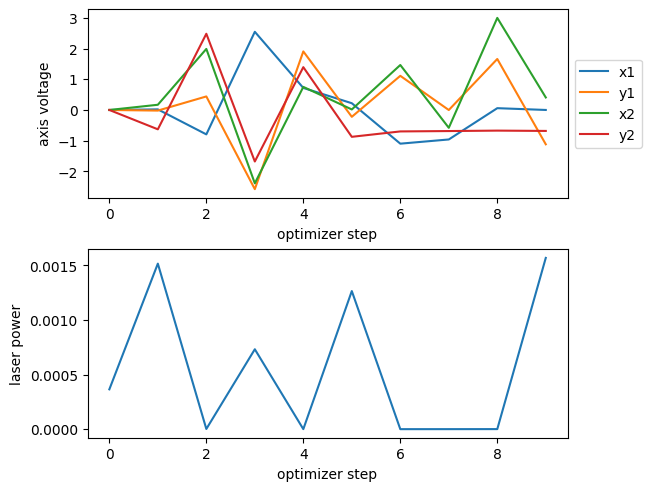

In [11]:
fig, axs = input_combined_output_init()
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [12]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x25db14fab40>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x25db16406b0>,
 'expt_thread': <Thread(Thread-6 (run), stopped daemon 23040)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 'x1_voltage': array([ 0.00000000e+00,  2.00000000e-02, -7.94963837e-01,  2.54708769e+00,
         7.18395375e-01,  2.19999134e-01, -1.09770146e+00, -9.60755865e-01,
         5.87948059e-02,  7.06041155e-04,  2.00000000e-02]),
 'y1_voltage': array([ 0.00000000e+00, -2.00000000e-02,  4.40857172e-01, -2.57974346e+00,
         1.90776445e+00, -2.22562904e-01,  1.11266452e+00, -1.49236975e-03,
         1.66169467e+00, -1.11817091e+00, -2.00000000e-02]),
 'x2_voltage': array([ 0.        ,  0.17      ,  1.98901284, -2.38935747,  0.75230026,
         0.01684539,  1.46507157, -0.58078728,  3.        ,  0.40802479,
         0.17      ]),
 'y2_voltage': array([ 0.        , -0.63      ,  2.48326814, -1.67839559,  1.3

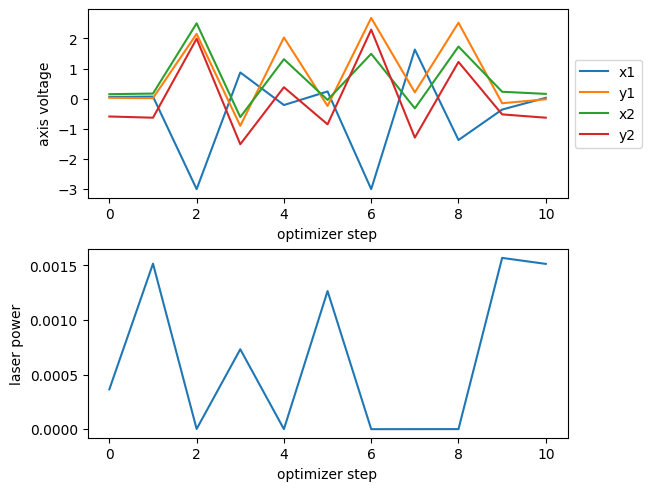

In [13]:
fig, axs = input_combined_output_init()
input_combined_output_plot(axs,
                           expt.x1_voltage_raster, expt.y1_voltage_raster,
                           expt.x2_voltage_raster, expt.y2_voltage_raster,
                           expt.power_raster)

In [ ]:
x1_opt, y1_opt, x2_opt, y2_opt, power_opt \
    = get_measure_opt(devices,
                      expt.x1_voltage_raster, expt.y1_voltage_raster,
                      expt.x2_voltage_raster, expt.y2_voltage_raster,
                      expt.power_raster)

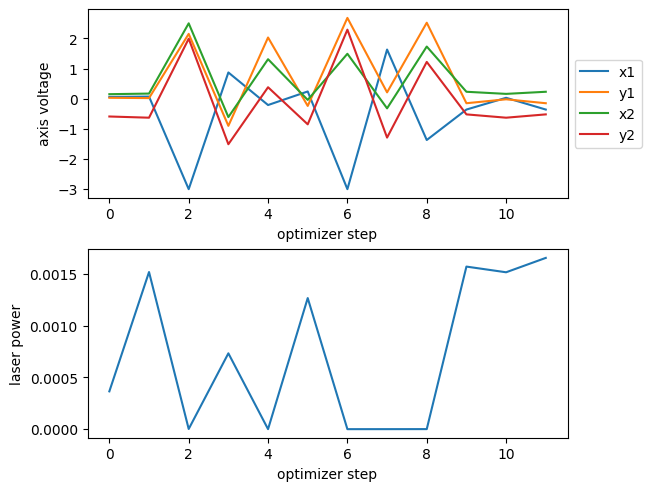

In [15]:
fig, axs = input_combined_output_init()
input_combined_output_plot(axs,
                           x1_opt, y1_opt,
                           x2_opt, y2_opt,
                           power_opt)